<a href="https://colab.research.google.com/github/irmcm/leakage-vs-honest-validation/blob/main/notebooks/validation_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leakage vs honest validation

What happens to a regression score when the data is split by patient instead
of at random?

The UCI Parkinson's Telemonitoring dataset holds ~140 voice recordings from
each of 42 patients, and the task is to predict a clinical severity score
(motor UPDRS) from voice measures. Because recordings repeat per patient, a
random split puts the same patient on both sides. A model can then recognise
the patient rather than the condition.

The intended use of such a model is a patient it has never heard before.
This notebook measures how much of the reported performance survives that
requirement.

## Setup

In [1]:
!pip install -q ucimlrepo

In [2]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

RANDOM_STATE = 42

pt = fetch_ucirepo(id=189)
df = pt.data.original

print(df.shape)
print(df.columns.tolist())
df.head()

(5875, 22)
['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE', 'motor_UPDRS', 'total_UPDRS']


,subject#,age,sex,test_time,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,...,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE,motor_UPDRS,total_UPDRS
0,1,72,0,5.6431,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,...,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006,28.199,34.398
1,1,72,0,12.6660,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,...,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810,28.447,34.894
2,1,72,0,19.6810,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,...,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014,28.695,35.389
3,1,72,0,25.6470,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,...,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277,28.905,35.810
4,1,72,0,33.6420,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,...,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361,29.187,36.375


In [3]:
# Confirm the column holding the patient identifier
subject_col = [c for c in df.columns if "subject" in c.lower()]
print("Aday sütun:", subject_col)

col = subject_col[0]
print("Hasta sayısı:", df[col].nunique())
print("Toplam kayıt:", len(df))
print("Hasta başına kayıt:")
print(df[col].value_counts().describe())

Aday sütun: ['subject#']
Hasta sayısı: 42
Toplam kayıt: 5875
Hasta başına kayıt:
count     42.000000
mean     139.880952
std       15.542550
min      101.000000
25%      130.000000
50%      141.000000
75%      149.750000
max      168.000000
Name: count, dtype: float64


In [4]:
target_col = "motor_UPDRS"

drop_cols = [col, "motor_UPDRS", "total_UPDRS"]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df[target_col]
groups = df[col]

print("Öznitelik sayısı:", X.shape[1])
print(feature_cols)

Öznitelik sayısı: 19
['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


##1. Random K- Fold

Rows split at random, so patients appear in both training and test folds.
This is the most common setup in published work on this dataset.



In [5]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Ridge": Ridge(alpha=1.0),
}

cv_random = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores_random = {}
for name, est in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("est", est)])
    s = cross_val_score(pipe, X, y, cv=cv_random, scoring="r2")
    scores_random[name] = s
    print(f"{name:15s} Random K-Fold R²: {s.round(3)} | Ortalama: {s.mean():.3f}")

Random Forest   Random K-Fold R²: [0.974 0.974 0.98  0.962 0.972] | Ortalama: 0.972
Ridge           Random K-Fold R²: [0.122 0.181 0.117 0.162 0.161] | Ortalama: 0.149


##2. GroupKFold by patient

Same models, same features, same metric. The only change is that no patient
appears on both sides of a split.

In [6]:
from sklearn.model_selection import GroupKFold

cv_group = GroupKFold(n_splits=5)

scores_group = {}
for name, est in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("est", est)])
    s = cross_val_score(pipe, X, y, groups=groups, cv=cv_group, scoring="r2")
    scores_group[name] = s
    print(f"{name:15s} GroupKFold R²: {s.round(3)} | Ortalama: {s.mean():.3f}")

Random Forest   GroupKFold R²: [-2.293 -0.349 -0.012  0.271 -1.539] | Ortalama: -0.784
Ridge           GroupKFold R²: [-0.833 -0.104 -0.535 -0.109 -0.384] | Ortalama: -0.393


#### How bad is a negative R²?

In [7]:
from sklearn.dummy import DummyRegressor

scores_dummy = cross_val_score(
    DummyRegressor(strategy="mean"), X, y,
    groups=groups, cv=GroupKFold(n_splits=5), scoring="r2")

print(f"{'Dummy (mean)':15s} GroupKFold R²: {scores_dummy.round(3)} | Mean: {scores_dummy.mean():.3f}")

Dummy (mean)    GroupKFold R²: [-0.69  -0.026 -0.027 -0.005 -0.396] | Mean: -0.229


#### Where does the leak come from?

In [8]:
feature_cols_no_time = [c for c in feature_cols if c != "test_time"]
X_no_time = df[feature_cols_no_time]

scores_group_no_time = {}
for name, est in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("est", est)])
    s = cross_val_score(pipe, X_no_time, y, groups=groups,
                        cv=GroupKFold(n_splits=5), scoring="r2")
    scores_group_no_time[name] = s
    print(f"{name:15s} GroupKFold, no test_time R²: {s.round(3)} | Mean: {s.mean():.3f}")

Random Forest   GroupKFold, no test_time R²: [-1.971 -0.312 -0.028  0.345 -1.453] | Mean: -0.684
Ridge           GroupKFold, no test_time R²: [-0.851 -0.119 -0.543 -0.124 -0.372] | Mean: -0.402


## 3. Leakage from feature selection

If features are selected once on the full dataset, the
selection has already seen the test folds. Repeating the selection inside
each fold removes that advantage.

In [9]:
from sklearn.feature_selection import SelectKBest, f_regression

K = 8

selector_all = SelectKBest(f_regression, k=K).fit(X, y)
X_selected_once = X.iloc[:, selector_all.get_support()]

scores_leaky_fs, scores_honest_fs = {}, {}

for name, est in models.items():
    # Leaky: selection done once on the full dataset
    pipe_leaky = Pipeline([("scaler", StandardScaler()), ("est", est)])
    s_leaky = cross_val_score(pipe_leaky, X_selected_once, y,
                              groups=groups, cv=GroupKFold(n_splits=5), scoring="r2")

    # Honest: selection repeated inside each fold
    pipe_honest = Pipeline([
        ("select", SelectKBest(f_regression, k=K)),
        ("scaler", StandardScaler()),
        ("est", est)])
    s_honest = cross_val_score(pipe_honest, X, y,
                               groups=groups, cv=GroupKFold(n_splits=5), scoring="r2")

    scores_leaky_fs[name] = s_leaky
    scores_honest_fs[name] = s_honest

    print(f"{name}")
    print(f"  Seçim tüm veride:    {s_leaky.round(3)} | Ortalama: {s_leaky.mean():.3f}")
    print(f"  Seçim katman içinde: {s_honest.round(3)} | Ortalama: {s_honest.mean():.3f}")

Random Forest
  Seçim tüm veride:    [-1.841 -0.474  0.03   0.238 -1.3  ] | Ortalama: -0.669
  Seçim katman içinde: [-1.841 -0.526  0.059  0.205 -1.582] | Ortalama: -0.737
Ridge
  Seçim tüm veride:    [-0.743  0.136 -0.105 -0.035 -0.211] | Ortalama: -0.191
  Seçim katman içinde: [-0.743 -0.153 -0.234  0.07  -0.428] | Ortalama: -0.298


#### Does the model rank patients correctly?

R² measures absolute accuracy. If a model learns the right relationship but
misses each new patient's baseline severity level, R² stays negative while
rank correlation stays positive. Spearman separates the two.

In [10]:
from sklearn.base import clone
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

cv_group = GroupKFold(n_splits=5)

for name, est in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("est", est)])
    r2s, rhos = [], []

    for train_idx, test_idx in cv_group.split(X, y, groups=groups):
        m = clone(pipe)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred = m.predict(X.iloc[test_idx])
        true = y.iloc[test_idx]

        r2s.append(r2_score(true, pred))
        rhos.append(spearmanr(true, pred).statistic)

    r2s, rhos = np.array(r2s), np.array(rhos)
    print(f"{name}")
    print(f"  R²:       {r2s.round(3)} | Ortalama: {r2s.mean():.3f}")
    print(f"  Spearman: {rhos.round(3)} | Ortalama: {rhos.mean():.3f}")

Random Forest
  R²:       [-2.293 -0.349 -0.012  0.271 -1.539] | Ortalama: -0.784
  Spearman: [-0.212  0.116  0.702  0.621 -0.047] | Ortalama: 0.236
Ridge
  R²:       [-0.833 -0.104 -0.535 -0.109 -0.384] | Ortalama: -0.393
  Spearman: [-0.135  0.018  0.191  0.193  0.423] | Ortalama: 0.138


## Summary

In [11]:
rows = []

def add(setup, score_dict):
    for name, s in score_dict.items():
        rows.append({"setup": setup, "model": name,
                     "mean_r2": s.mean(), "std": s.std()})

add("Random K-Fold", scores_random)
add("GroupKFold", scores_group)
add("GroupKFold, no test_time", scores_group_no_time)
add("GroupKFold + FS on full data", scores_leaky_fs)
add("GroupKFold + FS inside CV", scores_honest_fs)

rows.append({"setup": "GroupKFold", "model": "Dummy (mean)",
             "mean_r2": scores_dummy.mean(), "std": scores_dummy.std()})

summary = pd.DataFrame(rows)
summary.round(3)

,setup,model,mean_r2,std
0,Random K-Fold,Random Forest,0.972,0.006
1,Random K-Fold,Ridge,0.149,0.025
2,GroupKFold,Random Forest,-0.784,0.974
3,GroupKFold,Ridge,-0.393,0.275
4,"GroupKFold, no test_time",Random Forest,-0.684,0.880
5,"GroupKFold, no test_time",Ridge,-0.402,0.276
6,GroupKFold + FS on full data,Random Forest,-0.669,0.790
7,GroupKFold + FS on full data,Ridge,-0.191,0.298
8,GroupKFold + FS inside CV,Random Forest,-0.737,0.837
9,GroupKFold + FS inside CV,Ridge,-0.298,0.274


## Figures

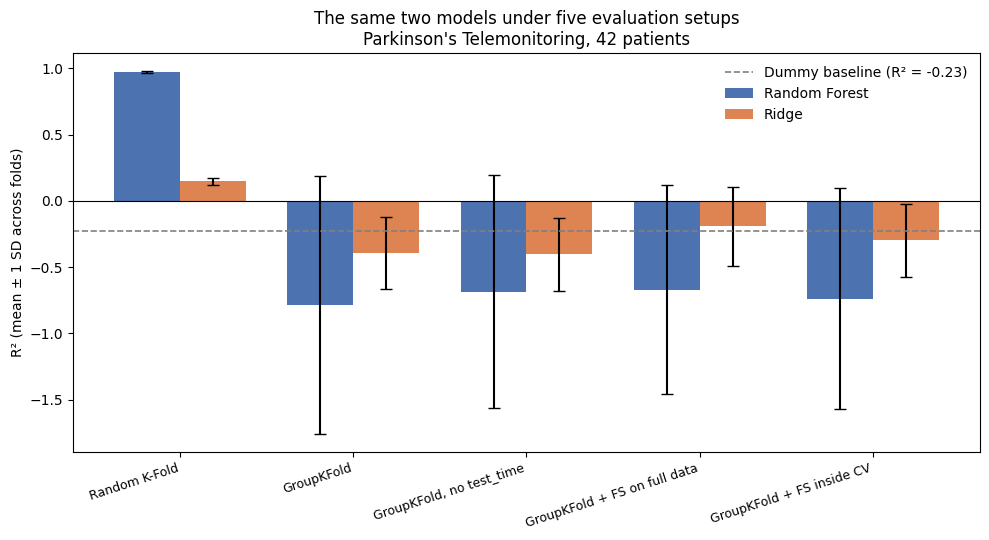

In [12]:
import matplotlib.pyplot as plt

setup_order = ["Random K-Fold", "GroupKFold", "GroupKFold, no test_time",
               "GroupKFold + FS on full data", "GroupKFold + FS inside CV"]

sub = summary[summary["model"] != "Dummy (mean)"]
piv_mean = sub.pivot(index="setup", columns="model", values="mean_r2").reindex(setup_order)
piv_std = sub.pivot(index="setup", columns="model", values="std").reindex(setup_order)

x = np.arange(len(setup_order))
w = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(x - w/2, piv_mean["Random Forest"], w, yerr=piv_std["Random Forest"],
       capsize=4, label="Random Forest", color="#4C72B0")
ax.bar(x + w/2, piv_mean["Ridge"], w, yerr=piv_std["Ridge"],
       capsize=4, label="Ridge", color="#DD8452")

ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(scores_dummy.mean(), color="gray", linestyle="--", linewidth=1.2,
           label=f"Dummy baseline (R² = {scores_dummy.mean():.2f})")

ax.set_xticks(x)
ax.set_xticklabels(setup_order, rotation=18, ha="right", fontsize=9)
ax.set_ylabel("R² (mean ± 1 SD across folds)")
ax.set_title("The same two models under five evaluation setups\n"
             "Parkinson's Telemonitoring, 42 patients")
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("validation_comparison.png", dpi=150)
plt.show()

## What this shows

The gap between the first and second setup is the whole point. Random Forest
reaches R² = 0.97 when rows are split at random, and drops to -0.78 when
patients are kept whole. Same model, same features, same metric. Only the
split changed.

The optimistic setup also hides how uncertain it is. Across folds the
standard deviation is 0.006 under random splitting and 0.97 under
patient-level splitting, so the inflated number looks far more precise than
it has any right to.

There's a second cost that's easy to miss. Under random splitting Random
Forest (0.97) looks vastly better than Ridge (0.15), so anyone choosing a
model from that table would drop Ridge immediately. Under patient-level
splitting the ranking flips and Ridge is less bad in every setup. The
flexible model wasn't better at the task, it was better at exploiting the
leak.

Dropping `test_time` recovers only part of the gap for Random Forest
(-0.78 to -0.68) and nothing at all for Ridge, so the shortcut isn't one
column. It's spread across the voice measures, which are speaker-specific
by nature.

The feature selection comparison didn't work out. Selecting inside the CV
loop instead of on the full dataset moves the mean by about 0.07, while the
fold-to-fold standard deviation is 0.8 to 0.9. That's well below the noise,
and calling it a finding would repeat exactly the mistake this notebook is
about. It doesn't mean selection bias is harmless, only that patient leakage
drowns it out here.

Rank correlation doesn't rescue things either. Spearman averages 0.24 for
Random Forest under patient-level splitting, but the folds run from -0.21 to
0.70. That's a hint, not a result.

## The real constraint

There are 5875 rows here but only 42 independent units. Patient-level
splitting trains on 33 patients and tests on 9, which is nowhere near enough
to learn how the relationship between voice and severity shifts from person
to person. The huge spread across folds follows directly from that.

This doesn't mean the voice measures are useless. It means the dataset can
answer a within-patient question, like tracking progression in someone
already enrolled, and can't answer the between-patient one of predicting
severity for a person the model has never heard. Scores above 0.9 on this
dataset are usually answering the first question while looking like they
answer the second.